# Human Activity Recognition with Wifi

In [33]:
import numpy as np
import numpy.random as rnd
import torch
import matplotlib.pyplot as plt

from models.DopplerDataset import * 
from models.SHARP import *
from utilities.training import *
from utilities.plotting import *
from utilities.dataset_separation import *

from time import time 
from torchvision.transforms import Compose, ToTensor, RandomHorizontalFlip, RandomVerticalFlip
from torch.utils.data import DataLoader
from os import listdir, makedirs, path
from glob import glob
from tqdm import tqdm

%load_ext autoreload
%autoreload 2


###############  GLOBAL VARIABLES  #################
DEBUG_MODE                 = True

PERFORM_DATASET_SEPARATION = True
DATASET_PATH               = "doppler_traces/S2*"
TEST_DATASET_FRACTION      = 1
DOPPLER_TRACE_SIZE         = 340
ACTIVITIES                 = ['W', 'E', 'R', 'J', 'L']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Separating training dataset and test dataset

In [7]:
'''
    We split each Doppler trace in DATASET_PATH into several Doppler sub-traces of size DOPPLER_TRACE_SIZE,
    then we randomly split each collection of sub-traces into a train/test dataset folder.
'''

create_test_dataset(DATASET_PATH, DOPPLER_TRACE_SIZE)

# train_dataset = DATASET_PATH.split('/')[0] + "_train"
# test_dataset  = DATASET_PATH.split('/')[0] + "_test"
# if PERFORM_DATASET_SEPARATION and (train_dataset not in listdir()) and (test_dataset not in listdir()):
#     subdir_list = sorted([name for name in glob(DATASET_PATH) if path.isdir(name)])

#     # Counting number of images in DATASET_PATH
#     traces_number = 0
#     for subdir in subdir_list:
#         traces_number += len(glob(subdir))
#     print(f"Dataset {DATASET_PATH} contains {traces_number} traces.\nProceding to create training dataset with {int((1-TEST_DATASET_FRACTION)*traces_number)} traces and test dataset with {int(TEST_DATASET_FRACTION*traces_number)} traces...\n")

#     # Creating train and test datasets
#     makedirs(train_dataset, exist_ok=True)
#     makedirs(test_dataset, exist_ok=True)

#     # Splitting a trace in many sub-traces and randomly assigning them to train/test dataset
#     for subdir in subdir_list:
#         for trace_name in sorted(listdir(subdir)):
#             # Only traces whose label is in ACTIVITIES are used for training/testing
#             if trace_name.split('_')[1][0] in ACTIVITIES:
#                 trace_path = subdir+'/'+trace_name
#                 full_trace = np.load(trace_path, allow_pickle=True)
#                 N_images = full_trace.shape[0]//DOPPLER_TRACE_SIZE

#                 for i in range(N_images):
#                     # Name of sub-trace is the one the original full trace + an index to distinguish
#                     if rnd.uniform()<TEST_DATASET_FRACTION:
#                         np.save(test_dataset+'/'+trace_name[:-4]+f"-{i}", full_trace[i*DOPPLER_TRACE_SIZE:(i+1)*DOPPLER_TRACE_SIZE, :], allow_pickle=True)
#                     else:
#                         np.save(train_dataset+'/'+trace_name[:-4]+f"-{i}", full_trace[i*DOPPLER_TRACE_SIZE:(i+1)*DOPPLER_TRACE_SIZE, :], allow_pickle=True)

#     print("Train and test datasets created successfully!")
# else:
#     print("Datasets are already splitted!")

Creating doppler_traces_test
Train and test datasets created successfully!


## Loading Dataset

In [8]:
transforms = Compose([
    RandomVerticalFlip(),
    RandomHorizontalFlip()
])

Loading dataset doppler_traces_train in memory...


3256it [00:01, 1878.32it/s]


Dataset is loaded!

---------- DATASET INFO ----------

Dataset directory:
doppler_traces_train
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}

----------------------------------

Loading dataset doppler_traces_test in memory...


2816it [00:01, 2040.34it/s]


Dataset is loaded!

---------- DATASET INFO ----------

Dataset directory:
doppler_traces_test
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}

----------------------------------



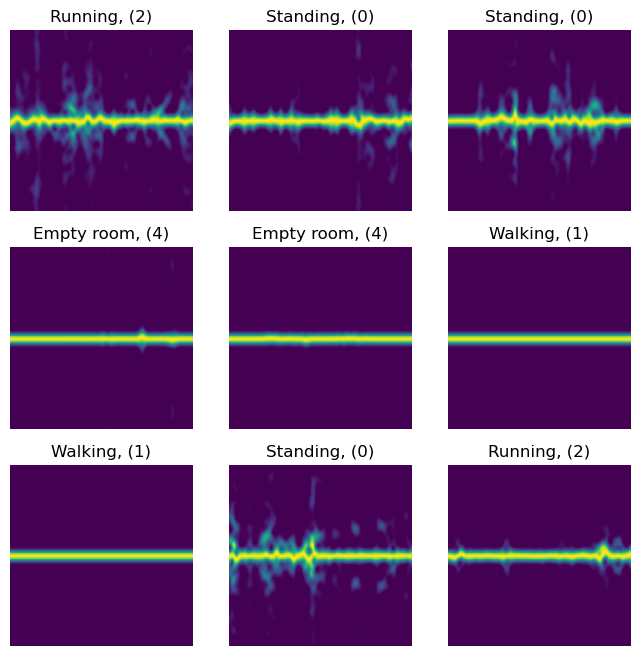

In [38]:
batch_size = 128
train_dataset  = DopplerDataset("doppler_traces_train", ACTIVITIES)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_dataset.getInfo()

test_dataset  = DopplerDataset("doppler_traces_test", ACTIVITIES)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)
test_dataset.getInfo()

labels_map = {
    0: "Standing",
    1: "Walking",
    2: "Running",
    3: "Standing Up",
    4: "Empty room",
    5: "Sitting",
    6: "Moving arm",
    7: "Jumping"
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols*rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(f"{labels_map[int(label)]}, ({label})")
    plt.axis("off")
    plt.imshow(img[0,:,:], aspect='auto')
plt.show()

## Training of SHARP architecure

In [29]:
sharp_model = SHARP(n_features=len(ACTIVITIES))

learning_rate = 1e-4
device    = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=sharp_model.parameters(), lr=learning_rate)

if DEBUG_MODE:
    #### CHECKING DATA TYPES 
    x, y = next(iter(train_dataloader))
    print(x.dtype)
    print(next(sharp_model.parameters()).dtype)
    ### DEVICE
    print(f"Device: {device}")

torch.float32
torch.float32
Device: mps


In [30]:
epochs = 20
train_loss, test_loss, _ = train_model(sharp_model, train_dataloader, test_dataloader, epochs, loss_fn, optimizer, device, verbosity=True)

Starting model training...
Completed epochs: 0/20 ------ Time (total): 0.00 ------ Time (relative): 0.00

Loss: 1.63589e+00 --- Samples:   128/ 3256
Loss: 1.63795e+00 --- Samples:  1408/ 3256
Loss: 1.59329e+00 --- Samples:  2688/ 3256
Test Error: 
 Accuracy: 29.0%, Avg loss: 1.577734 

Completed epochs: 1/20 ------ Time (total): 3.30 ------ Time (relative): 3.30

Loss: 1.60221e+00 --- Samples:   128/ 3256
Loss: 1.59140e+00 --- Samples:  1408/ 3256
Loss: 1.60336e+00 --- Samples:  2688/ 3256
Test Error: 
 Accuracy: 28.6%, Avg loss: 1.598621 

Completed epochs: 2/20 ------ Time (total): 6.23 ------ Time (relative): 2.93

Loss: 1.60509e+00 --- Samples:   128/ 3256
Loss: 1.55342e+00 --- Samples:  1408/ 3256
Loss: 1.58651e+00 --- Samples:  2688/ 3256
Test Error: 
 Accuracy: 36.9%, Avg loss: 1.615488 

Completed epochs: 3/20 ------ Time (total): 9.21 ------ Time (relative): 2.98

Loss: 1.56233e+00 --- Samples:   128/ 3256
Loss: 1.56863e+00 --- Samples:  1408/ 3256
Loss: 1.54804e+00 --- Sample

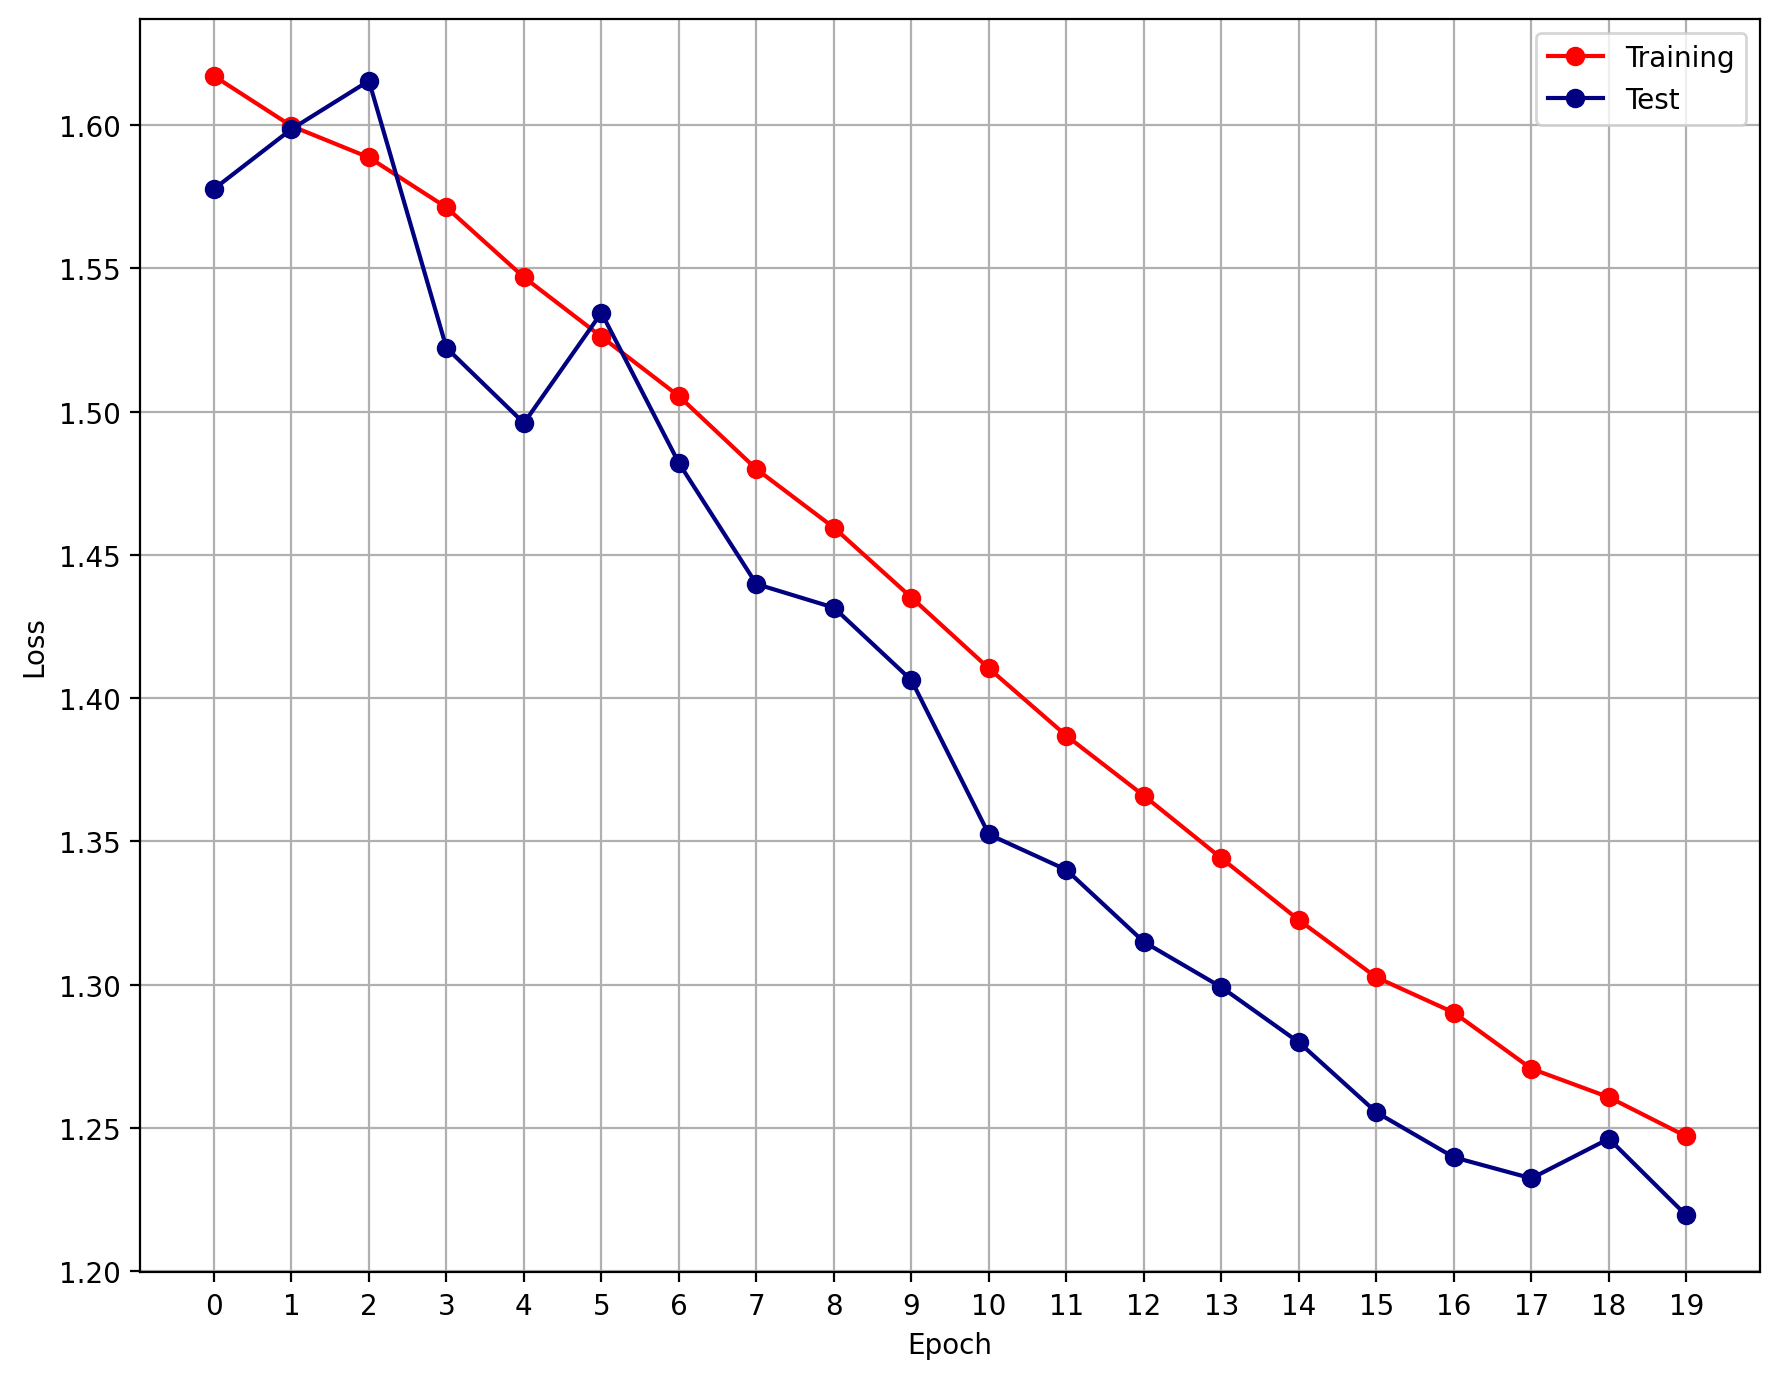

In [31]:
plot_loss(train_loss, test_loss)